In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!pip install kaggle

# Copy kaggle.json into the right place
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/major_project/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [5]:
!kaggle datasets download -d rawsi18/military-assets-dataset-12-classes-yolo8-format -p /content/drive/MyDrive/major_project --force


Dataset URL: https://www.kaggle.com/datasets/rawsi18/military-assets-dataset-12-classes-yolo8-format
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.83G/3.83G [02:04<00:00, 17.6MB/s]
100% 3.83G/3.83G [02:04<00:00, 33.1MB/s]


In [6]:
!rm -rf /content/drive/MyDrive/major_project/military_object_dataset
!unzip -o /content/drive/MyDrive/major_project/military-assets-dataset-12-classes-yolo8-format.zip -d /content/drive/MyDrive/major_project/military_object_dataset


Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/major_project/military_object_dataset/military_object_dataset/val/images/011492.jpg  
  inflating: /content/drive/MyDrive/major_project/military_object_dataset/military_object_dataset/val/images/011493.jpg  
  inflating: /content/drive/MyDrive/major_project/military_object_dataset/military_object_dataset/val/images/011494.jpg  
  inflating: /content/drive/MyDrive/major_project/military_object_dataset/military_object_dataset/val/images/011495.jpg  
  inflating: /content/drive/MyDrive/major_project/military_object_dataset/military_object_dataset/val/images/011496.jpg  
  inflating: /content/drive/MyDrive/major_project/military_object_dataset/military_object_dataset/val/images/011497.jpg  
  inflating: /content/drive/MyDrive/major_project/military_object_dataset/military_object_dataset/val/images/011498.jpg  
  inflating: /content/drive/MyDrive/major_project/military_object_dataset/military_object_datas

In [7]:
!mv /content/drive/MyDrive/major_project/military_object_dataset/*/* /content/drive/MyDrive/major_project/military_object_dataset/ || echo "Already flat"


In [8]:
!ls /content/drive/MyDrive/major_project/military_object_dataset
!ls /content/drive/MyDrive/major_project/military_object_dataset/train | head
!ls /content/drive/MyDrive/major_project/military_object_dataset/val | head


dataset.md  military_dataset.yaml  military_object_dataset  test  train  val
images
labels
images
labels


In [9]:
yaml_content = """
train: /content/drive/MyDrive/major_project/military_object_dataset/train/images
val: /content/drive/MyDrive/major_project/military_object_dataset/val/images

nc: 12
names: ['camouflage_soldier','weapon','military_tank','military_truck',
        'military_vehicle','civilian','soldier','civilian_vehicle',
        'military_artillery','trench','military_aircraft','drone']
"""

with open("/content/drive/MyDrive/major_project/military_dataset.yaml", "w") as f:
    f.write(yaml_content)

print("✅ YAML ready at /content/drive/MyDrive/major_project/military_dataset.yaml")


✅ YAML ready at /content/drive/MyDrive/major_project/military_dataset.yaml


In [11]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.4 MB/s eta 0:00:00


In [12]:
from ultralytics import YOLO

# Load YOLOv26 trained weights
model = YOLO("/content/drive/MyDrive/major_project/v26best.pt")

# Validate on dataset
metrics = model.val(
    data="/content/drive/MyDrive/major_project/military_dataset.yaml",
    batch=8,
    imgsz=640
)

print(metrics)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO26n summary (fused): 122 layers, 2,377,176 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 1.0±0.7 ms, read: 35.0±43.7 MB/s, size: 140.5 KB)
val: Scanning /content/drive/MyDrive/major_project/military_object_dataset/val/labels... 2941 images, 273 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2941/2941 36.6it/s 1:20
val: New cache created: /content/drive/MyDrive/major_project/military_object_dataset/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 368/368 1.6s/it 10:00
                   all       2941   

In [13]:
from ultralytics import YOLO

# Load YOLOv11 trained weights
model = YOLO("/content/drive/MyDrive/major_project/v11best.pt")

# Validate on dataset
metrics = model.val(
    data="/content/drive/MyDrive/major_project/military_dataset.yaml",
    batch=8,
    imgsz=640
)

print(metrics)


Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 101 layers, 2,584,492 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.6 ms, read: 13.5±13.0 MB/s, size: 70.2 KB)
val: Scanning /content/drive/MyDrive/major_project/military_object_dataset/val/labels.cache... 2941 images, 273 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2941/2941 456.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 368/368 1.9s/it 11:21
                   all       2941       5081      0.434      0.407      0.347      0.187
    camouflage_soldier        385        510      0.471      0.618      0.536      0.224
                weapon        222        358      0.304      0.559      0.354      0.169
         military_tank        938       1787      0.652      0.805      0.768      0.464
        military_truck         84        148      0.146      0.689      0.286       0.

In [14]:
from ultralytics import YOLO

# Load YOLOv8 trained weights
model = YOLO("/content/drive/MyDrive/major_project/v8best.pt")

# Validate on dataset
metrics = model.val(
    data="/content/drive/MyDrive/major_project/military_dataset.yaml",
    batch=8,
    imgsz=640
)

print(metrics)


Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.1 ms, read: 16.2±9.2 MB/s, size: 90.6 KB)
val: Scanning /content/drive/MyDrive/major_project/military_object_dataset/val/labels.cache... 2941 images, 273 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2941/2941 493.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 368/368 1.8s/it 10:56
                   all       2941       5081      0.405      0.386      0.313      0.169
    camouflage_soldier        385        510      0.433      0.493      0.374      0.148
                weapon        222        358       0.35      0.489       0.39      0.173
         military_tank        938       1787      0.628      0.785       0.74      0.442
        military_truck         84        148      0.201      0.703      0.327      0.171
 

In [23]:
from ultralytics import YOLO

# Load YOLOv11 trained weights
model = YOLO("/content/drive/MyDrive/major_project/best.pt")

# Validate on dataset
metrics = model.val(
    data="/content/drive/MyDrive/major_project/military_dataset.yaml",
    batch=8,
    imgsz=640
)

print(metrics)


Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 101 layers, 2,584,492 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 3.7±5.8 ms, read: 16.4±10.8 MB/s, size: 60.4 KB)
val: Scanning /content/drive/MyDrive/major_project/military_object_dataset/val/labels.cache... 2941 images, 273 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2941/2941 725.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 368/368 1.7s/it 10:20
                   all       2941       5081      0.704      0.542      0.594      0.408
    camouflage_soldier        385        510      0.827       0.82       0.86      0.496
                weapon        222        358      0.761      0.589      0.658      0.495
         military_tank        938       1787      0.795        0.9      0.889       0.63
        military_truck         84        148      0.621      0.669      0.647      0.4

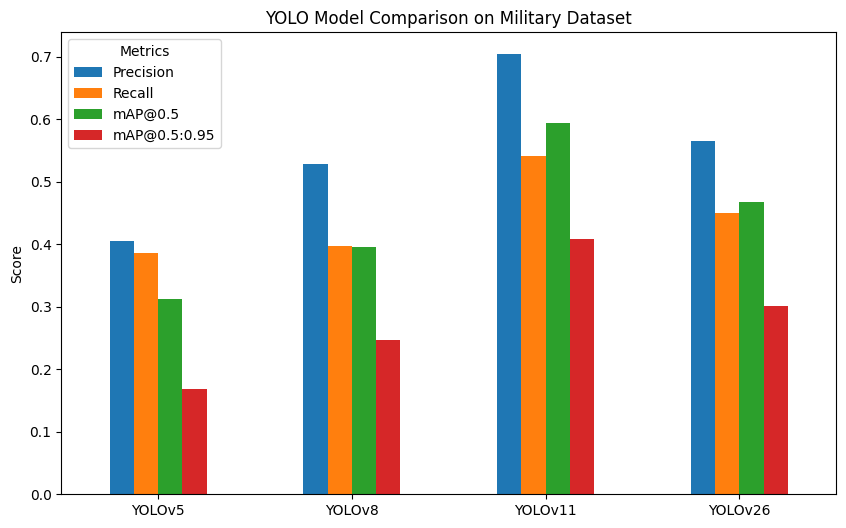

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Metrics dictionary
results = {
    "YOLOv5": {"Precision": 0.405, "Recall": 0.386, "mAP@0.5": 0.313, "mAP@0.5:0.95": 0.169},
    "YOLOv8": {"Precision": 0.528, "Recall": 0.398, "mAP@0.5": 0.396, "mAP@0.5:0.95": 0.247},
    "YOLOv11": {"Precision": 0.704, "Recall": 0.542, "mAP@0.5": 0.594, "mAP@0.5:0.95": 0.408},
    "YOLOv26": {"Precision": 0.565, "Recall": 0.450, "mAP@0.5": 0.467, "mAP@0.5:0.95": 0.302},
}

# Convert to DataFrame
df = pd.DataFrame(results).T

# Plot grouped bar chart
df.plot(kind="bar", figsize=(10,6))
plt.title("YOLO Model Comparison on Military Dataset")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.show()


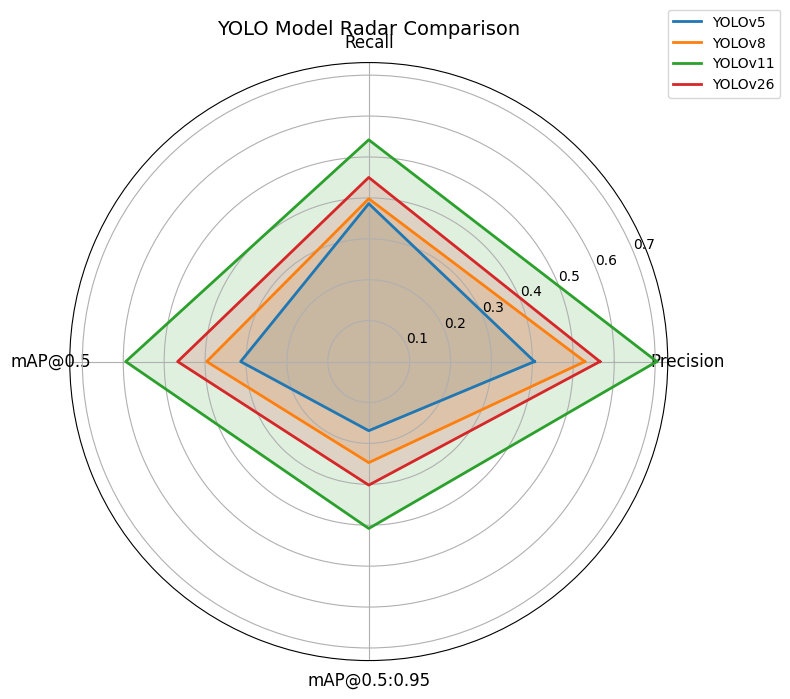

In [25]:
import numpy as np
import matplotlib.pyplot as plt

labels = list(df.columns)
num_vars = len(labels)

# Angles for each axis
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Bigger figure for clarity
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

# Plot each model
for model, row in df.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=model, linewidth=2)
    ax.fill(angles, values, alpha=0.15)

# Set axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)

# Rotate labels to align with axes
for label, angle in zip(ax.get_xticklabels(), angles):
    label.set_rotation(angle * 180/np.pi)
    label.set_horizontalalignment("center")

# Title and legend
ax.set_title("YOLO Model Radar Comparison", fontsize=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()



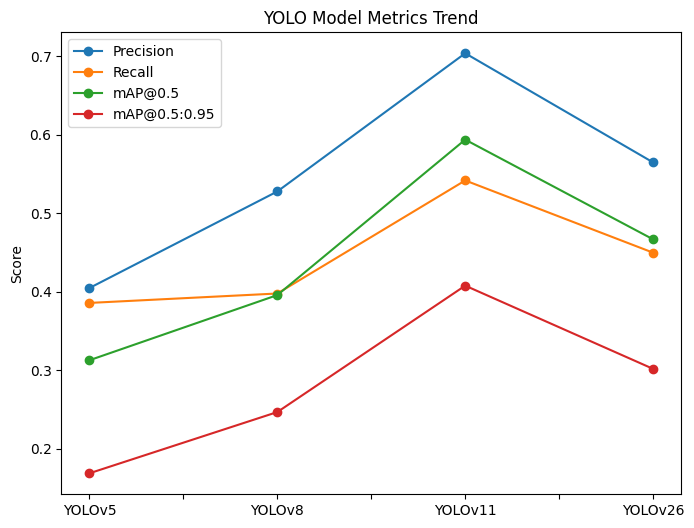

In [26]:
df.plot(kind="line", marker="o", figsize=(8,6))
plt.title("YOLO Model Metrics Trend")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()
